In [183]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
from datetime import date,timedelta
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [184]:
today = date.today()

d1 = today.strftime('%Y-%m-%d')
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime('%Y-%m-%d')
start_date = d2

stock_data = yf.download('AAPL', start = start_date, end = end_date, progress=False, auto_adjust=False)
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.droplevel(1)
stock_data

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-05-06,180.856049,181.710007,184.199997,180.419998,182.350006,78569700
2024-05-07,181.542770,182.399994,184.899994,181.320007,183.449997,77305800
2024-05-08,181.881195,182.740005,183.070007,181.449997,182.850006,45057100
2024-05-09,183.702591,184.570007,184.660004,182.110001,182.559998,48983000
2024-05-10,182.436859,183.050003,185.089996,182.130005,184.899994,50759500
...,...,...,...,...,...,...
2025-04-28,210.139999,210.139999,211.500000,207.460007,210.000000,38743100
2025-04-29,211.210007,211.210007,212.240005,208.369995,208.690002,36827600
2025-04-30,212.500000,212.500000,213.580002,206.669998,209.300003,52286500


Returns

In [185]:
stock_data['PrevClose'] = stock_data['Close'].shift(1)
stock_data

Price,Adj Close,Close,High,Low,Open,Volume,PrevClose
Date,,,,,,,
2024-05-06,180.856049,181.710007,184.199997,180.419998,182.350006,78569700,NaN
2024-05-07,181.542770,182.399994,184.899994,181.320007,183.449997,77305800,181.710007
2024-05-08,181.881195,182.740005,183.070007,181.449997,182.850006,45057100,182.399994
2024-05-09,183.702591,184.570007,184.660004,182.110001,182.559998,48983000,182.740005
2024-05-10,182.436859,183.050003,185.089996,182.130005,184.899994,50759500,184.570007
...,...,...,...,...,...,...,...
2025-04-28,210.139999,210.139999,211.500000,207.460007,210.000000,38743100,209.279999
2025-04-29,211.210007,211.210007,212.240005,208.369995,208.690002,36827600,210.139999
2025-04-30,212.500000,212.500000,213.580002,206.669998,209.300003,52286500,211.210007


In [186]:
#Calculate return
stock_data['Return'] = (stock_data['Close'] - stock_data['PrevClose']) / stock_data.PrevClose
stock_data

Price,Adj Close,Close,High,Low,Open,Volume,PrevClose,Return
Date,,,,,,,,
2024-05-06,180.856049,181.710007,184.199997,180.419998,182.350006,78569700,NaN,NaN
2024-05-07,181.542770,182.399994,184.899994,181.320007,183.449997,77305800,181.710007,0.003797
2024-05-08,181.881195,182.740005,183.070007,181.449997,182.850006,45057100,182.399994,0.001864
2024-05-09,183.702591,184.570007,184.660004,182.110001,182.559998,48983000,182.740005,0.010014
2024-05-10,182.436859,183.050003,185.089996,182.130005,184.899994,50759500,184.570007,-0.008235
...,...,...,...,...,...,...,...,...
2025-04-28,210.139999,210.139999,211.500000,207.460007,210.000000,38743100,209.279999,0.004109
2025-04-29,211.210007,211.210007,212.240005,208.369995,208.690002,36827600,210.139999,0.005092
2025-04-30,212.500000,212.500000,213.580002,206.669998,209.300003,52286500,211.210007,0.006108


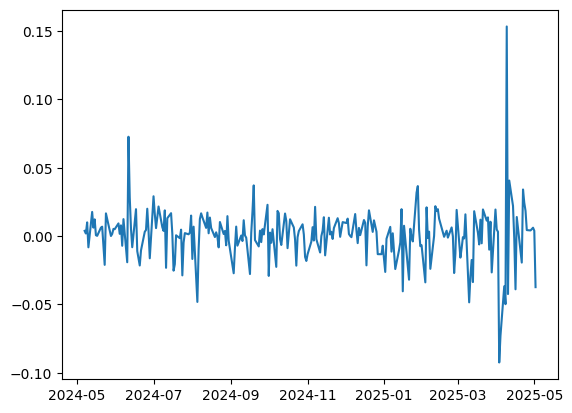

In [187]:
plt.plot(stock_data.Return)

In [188]:
#Normalize data
series = stock_data['Return'].values[1:].reshape(-1,1)

scaler = StandardScaler()
scaler.fit(series[:len(series) // 2])
series = scaler.transform(series).flatten()

In [189]:
#Build data set
T = 20
D = 1
X = []
Y = []

for t in range (len(series) - T):
    x = series[t:t+T]
    X.append(x)
    y = series[t+T]
    Y.append(y)
    
X = np.array(X).reshape(-1,T, 1)
Y = np.array(Y).reshape(-1,1)
N = len(X)
print(f'X-shape: {X.shape}, Y-shape: {Y.shape}')

X-shape: (228, 20, 1), Y-shape: (228, 1)


In [190]:
#set device
device = torch.device('mps')
print(device)

mps


In [191]:
#RNN class
class RNN(nn.Module):
    def __init__(self, n_inputs, n_hidden, n_rnnlayers, n_outputs):
        super(RNN, self).__init__()
        self.D = n_inputs
        self.M = n_hidden
        self.K = n_outputs
        self.L = n_rnnlayers
        
        self.rnn = nn.RNN(
            input_size= self.D,
            hidden_size= self.M,
            num_layers= self.L,
            nonlinearity='relu',
            batch_first=True)
        self.fc = nn.Linear(self.M, self.K)
        
    def forward (self,X):
        h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
        
        out, _ = self.rnn(X, h0)
        out = self.fc(out[:, -1, :])
        return out

In [192]:
model = RNN(n_inputs=1, n_hidden=5 , n_rnnlayers=1, n_outputs=1)
model.to(device)

RNN(
  (rnn): RNN(1, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=1, bias=True)
)

In [193]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [194]:
X_train = torch.from_numpy(X[:-N//2].astype(np.float32))
X_test = torch.from_numpy(X[-N//2:].astype(np.float32))
y_train = torch.from_numpy(Y[:-N//2].astype(np.float32)) 
y_test = torch.from_numpy(Y[-N//2:].astype(np.float32))

In [195]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [196]:
#Training

def full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=200):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        optimizer.zero_grad()
        
        #Forward pass 
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        #Backward and optimize
        loss.backward()
        optimizer.step()
        
        #Save losses
        train_losses[i] = loss.item()
        
        #Test loss
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses[i] = test_loss.item()
        
        if (i + 1) % 5 == 0:
            print(f'Epoch {i+1}/{epochs}, Train loss: {loss.item():.4f}, Test loss: {test_loss.item():.4f}')
    return train_losses, test_losses

In [197]:
train_losses, test_losses = full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test)

Epoch 5/200, Train loss: 1.1532, Test loss: 2.8871
Epoch 10/200, Train loss: 1.0925, Test loss: 2.8811
Epoch 15/200, Train loss: 1.0687, Test loss: 2.9250
Epoch 20/200, Train loss: 1.0621, Test loss: 2.9458
Epoch 25/200, Train loss: 1.0606, Test loss: 2.9447
Epoch 30/200, Train loss: 1.0545, Test loss: 2.9442
Epoch 35/200, Train loss: 1.0472, Test loss: 2.9520
Epoch 40/200, Train loss: 1.0438, Test loss: 2.9731
Epoch 45/200, Train loss: 1.0387, Test loss: 3.0087
Epoch 50/200, Train loss: 1.0307, Test loss: 3.0521
Epoch 55/200, Train loss: 1.0221, Test loss: 3.1687
Epoch 60/200, Train loss: 1.0158, Test loss: 3.1671
Epoch 65/200, Train loss: 1.0097, Test loss: 3.1884
Epoch 70/200, Train loss: 0.9995, Test loss: 3.3049
Epoch 75/200, Train loss: 0.9882, Test loss: 3.4677
Epoch 80/200, Train loss: 0.9788, Test loss: 3.5744
Epoch 85/200, Train loss: 0.9680, Test loss: 3.6237
Epoch 90/200, Train loss: 0.9549, Test loss: 3.8374
Epoch 95/200, Train loss: 0.9370, Test loss: 4.0802
Epoch 100/200

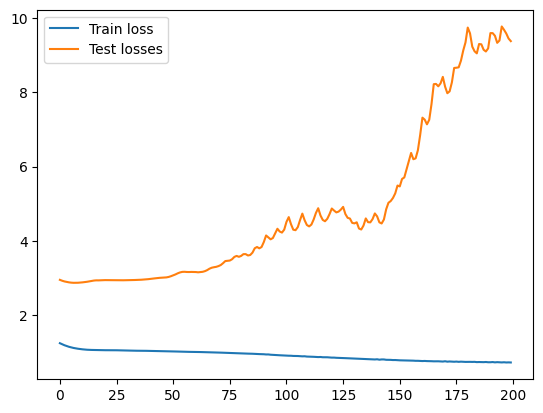

In [198]:
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test losses')
plt.legend()
plt.show()

Better model

In [199]:
today = date.today()

d1 = today.strftime('%Y-%m-%d')
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime('%Y-%m-%d')
start_date = d2

stock_data = yf.download('AAPL', start = start_date, end = end_date, progress=False, auto_adjust=False)
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = stock_data.columns.droplevel(1)
stock_data

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-05-06,180.856049,181.710007,184.199997,180.419998,182.350006,78569700
2024-05-07,181.542770,182.399994,184.899994,181.320007,183.449997,77305800
2024-05-08,181.881195,182.740005,183.070007,181.449997,182.850006,45057100
2024-05-09,183.702591,184.570007,184.660004,182.110001,182.559998,48983000
2024-05-10,182.436859,183.050003,185.089996,182.130005,184.899994,50759500
...,...,...,...,...,...,...
2025-04-28,210.139999,210.139999,211.500000,207.460007,210.000000,38743100
2025-04-29,211.210007,211.210007,212.240005,208.369995,208.690002,36827600
2025-04-30,212.500000,212.500000,213.580002,206.669998,209.300003,52286500


In [200]:
stock_data['PrevClose'] = stock_data['Close'].shift(1)
stock_data['Return'] = (stock_data.Close - stock_data.PrevClose) / stock_data.PrevClose
stock_data

Price,Adj Close,Close,High,Low,Open,Volume,PrevClose,Return
Date,,,,,,,,
2024-05-06,180.856049,181.710007,184.199997,180.419998,182.350006,78569700,NaN,NaN
2024-05-07,181.542770,182.399994,184.899994,181.320007,183.449997,77305800,181.710007,0.003797
2024-05-08,181.881195,182.740005,183.070007,181.449997,182.850006,45057100,182.399994,0.001864
2024-05-09,183.702591,184.570007,184.660004,182.110001,182.559998,48983000,182.740005,0.010014
2024-05-10,182.436859,183.050003,185.089996,182.130005,184.899994,50759500,184.570007,-0.008235
...,...,...,...,...,...,...,...,...
2025-04-28,210.139999,210.139999,211.500000,207.460007,210.000000,38743100,209.279999,0.004109
2025-04-29,211.210007,211.210007,212.240005,208.369995,208.690002,36827600,210.139999,0.005092
2025-04-30,212.500000,212.500000,213.580002,206.669998,209.300003,52286500,211.210007,0.006108


In [201]:
input_data = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].values
target = stock_data.Return.values

In [202]:
T = 10
D = input_data.shape[1]
N = len(input_data) - T

In [203]:
Ntrain = len(input_data) * 2 //3
scaler = StandardScaler()
scaler.fit(input_data[:Ntrain + T -1])
input_data = scaler.transform(input_data)

In [204]:
X_train = np.zeros((Ntrain, T, D))
Y_train = np.zeros((Ntrain, 1))

for t in range (Ntrain):
    X_train[t, :, :] = input_data[t:t+T]
    Y_train[t] = (target[t+T] > 0)

In [205]:
X_test = np.zeros((N - Ntrain, T, D))
Y_test = np.zeros((N - Ntrain, 1))

for u in range(N - Ntrain):
    t = u + Ntrain
    X_test[u, :, :] = input_data[t:t+T]
    Y_test[u] = (target[t+T] > 0)

In [206]:
class RNN(nn.Module):
    def __init__(self, n_inputs, n_hidden, n_rnnlayers, n_outputs):
        super(RNN, self).__init__()
        self.D = n_inputs
        self.M = n_hidden
        self.K = n_outputs
        self.L = n_rnnlayers
        
        self.rnn = nn.LSTM(
            input_size= self.D,
            hidden_size= self.M,
            num_layers= self.L,
            batch_first=True)
        self.fc = nn.Linear(self.M, self.K)
        
    def forward (self,X):
        h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
        c0 = torch.zeros(self.L, X.size(0), self.M).to(device)
        
        out, _ = self.rnn(X, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [207]:
model = RNN(n_inputs=5, n_hidden=50 , n_rnnlayers=2, n_outputs=1)
model.to(device)

RNN(
  (rnn): LSTM(5, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [208]:
#Since it is binary classificication BCE instead of MSE
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [209]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(Y_train.astype(np.float32)) 
y_test = torch.from_numpy(Y_test.astype(np.float32))

In [210]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [211]:
#Training

def full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=300):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        optimizer.zero_grad()
        
        #Forward pass 
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        #Backward and optimize
        loss.backward()
        optimizer.step()
        
        #Save losses
        train_losses[i] = loss.item()
        
        #Test loss
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses[i] = test_loss.item()
        
        if (i + 1) % 5 == 0:
            print(f'Epoch {i+1}/{epochs}, Train loss: {loss.item():.4f}, Test loss: {test_loss.item():.4f}')
    return train_losses, test_losses

In [212]:
train_losses, test_losses = full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test)

Epoch 5/300, Train loss: 0.6568, Test loss: 0.6809
Epoch 10/300, Train loss: 0.6518, Test loss: 0.6860
Epoch 15/300, Train loss: 0.6482, Test loss: 0.6896
Epoch 20/300, Train loss: 0.6404, Test loss: 0.6909
Epoch 25/300, Train loss: 0.6213, Test loss: 0.7421
Epoch 30/300, Train loss: 0.6022, Test loss: 0.7313
Epoch 35/300, Train loss: 0.5858, Test loss: 0.7710
Epoch 40/300, Train loss: 0.5636, Test loss: 0.7652
Epoch 45/300, Train loss: 0.5299, Test loss: 0.9179
Epoch 50/300, Train loss: 0.4917, Test loss: 1.0673
Epoch 55/300, Train loss: 0.4573, Test loss: 1.3738
Epoch 60/300, Train loss: 0.4058, Test loss: 1.2571
Epoch 65/300, Train loss: 0.3481, Test loss: 1.2844
Epoch 70/300, Train loss: 0.2775, Test loss: 1.3963
Epoch 75/300, Train loss: 0.1863, Test loss: 1.6570
Epoch 80/300, Train loss: 0.2133, Test loss: 1.8939
Epoch 85/300, Train loss: 0.1472, Test loss: 2.0503
Epoch 90/300, Train loss: 0.1805, Test loss: 2.2449
Epoch 95/300, Train loss: 0.1071, Test loss: 2.3843
Epoch 100/300

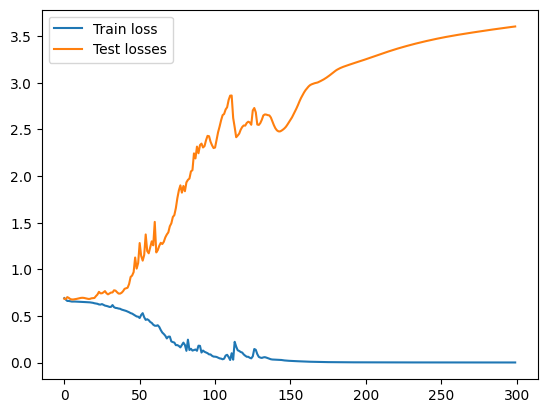

In [213]:
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test losses')
plt.legend()
plt.show()